# Groundwater Anomalies from GRACE and Hydrologic Components

#### J.T. Reager<sup>1</sup>, Felix Landerer<sup>1</sup>, Munish Sikka<sup>1</sup>, Emmy Killett<sup>1</sup>
#### <sup>1</sup>Jet Propulsion Laboratory, California Institute of Technology, Pasadena, CA, USA

**Goal:**  
This notebook is an accessible, step-by-step introduction to the groundwater calculation process, especially the Python script `compute_groundwater.py`. It's aimed at hydrologists who want to understand how we:

1. Load time series for:
   - GRACE total water storage (TWS)
   - Snow Water Equivalent (SWE)
   - Soil moisture
   - Reservoir storage
2. Align, clean, and de-mean these datasets over a baseline period.
3. Compute **groundwater anomalies** and propagate uncertainties.
4. Save the results as CSV files (monthly, smoothed, calendar-year, and water-year).
5. Visualize the results with simple, publication-ready plots.

This notebook assumes the following local file layout (as in `run_all.py`):

- `run_all.py` is in the `scripts` subdirectory directly below this notebook.
- Input masked time series CSVs live in:  
  `project_root/input_data/masked_timeseries`
- Output CSVs will be written to:  
  `project_root/output`

We will **import the local module**:

```python
import scripts/run_all as ra


In [1]:
import os
from pathlib import Path
import argparse
import logging
import json
import re
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scripts.run_all as ra  # <--- the same local module imported in compute_groundwater.py

# Make plots a bit nicer
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 12,
})
print("Done.")

Done.


## Project options and directory structure

`run_all.py` defines a central `Options` class that knows:

- Where input data live (e.g. `timeseries_dir`)
- Where output and graphics should go
- Baseline periods, default basin name, etc.

The `compute_groundwater.py` script defines a subclass of `ra.Options`
to add some script-specific defaults (e.g. default filenames for input CSVs).

A very similar `Options` subclass is created below for this notebook.


In [2]:
class GroundwaterOptions(ra.Options):
    """
    Notebook-friendly version of the compute_groundwater.py Options class.

    This inherits from ra.Options (defined in run_all.py) and adds:
    - my_name
    - default file names for soil moisture, SWE, reservoirs, and GRACE
    - a default output filename template
    """

    def __init__(self) -> None:
        super().__init__()  # from run_all.Options: sets project_root, dirs, baseline, etc.

        # In a script, this would be Path(__file__).stem; in a notebook __file__ may not exist.
        self.my_name:                   str = "compute_groundwater_notebook"
        self.default_soil_moisture_csv: str = f"LATEST_{self.soil_moisture_model}_FOR_BASIN.csv"
        self.default_reservoirs_csv:    str = f"LATEST_{self.reservoirs_model}_FOR_BASIN.csv"
        self.default_swe_csv:           str = f"LATEST_{self.swe_model}_FOR_BASIN.csv"
        self.default_grace_csv:         str = "LATEST_GRACE_FOR_BASIN.csv"

        # Placeholder template; DATA_START/DATA_END will be filled later
        self.default_output_csv:        str = (
            f"anomaly_timeseries_groundwater_{self.default_basin_safename}_"
            f"DATA_START_to_DATA_END_created_on_CURRENT_DATETIME.csv"
        )
        
        # Baseline mode
        # 1: Subtract the mean from baseline_start to baseline_end.
        # 2: Subtract the value of the first data point.
        self.baseline_mode: int = 2
        
        #Title font size
        self.title_font:    int = 16

        # Ensure the time series output directory exists
        self.timeseries_dir.mkdir(parents=True, exist_ok=True)


# Instantiate options for this notebook
options = GroundwaterOptions()
print("Done.")


Done.


## Choose a basin and set up logging

We now choose a **basin** (e.g. `"California"`, `"Sacramento"`, `"San Joaquin"`,
`"Tulare-Buena Vista Lakes"`) and set up a simple logging configuration so that
we can see what the code is doing.

In `compute_groundwater.py`, arguments are parsed with `argparse`.  
Here, we mimic that behavior by creating a small `argparse.Namespace` and
attaching it to `options.args`.


In [49]:
# ---- User-configurable parameters for the notebook ----
# Basin options: "California", "Sacramento", "San Joaquin", "Tulare-Buena Vista Lakes"
chosen_basin = "Tulare-Buena Vista Lakes"   # <- change this to a different basin if you like
debug_mode   = False          # True for very chatty logging
full_mode    = False          # analogous to --full in run_all.py (not used heavily here)

# -------------------------------------------------------
# Create an argparse-like object so we can reuse script logic.
options.args = argparse.Namespace(
    basin=chosen_basin,
    soilm=options.default_soil_moisture_csv,  # placeholders, may be replaced
    reservoirs=options.default_reservoirs_csv,
    swe=options.default_swe_csv,
    grace=options.default_grace_csv,
    output=options.default_output_csv,
    full=full_mode,
    debug=debug_mode,
)

# Adjust logging level
options.log_mode = logging.DEBUG if debug_mode else logging.INFO
logging.basicConfig(
    level=options.log_mode,
    format="%(asctime)s - %(levelname)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    force=True,  # overwrite any previous basicConfig
)

logging.info(f"Using basin: {options.args.basin}")
logging.info(f"Timeseries directory: {options.timeseries_dir}")
logging.info(f"Output directory:     {options.output_dir}")
logging.info("Done.")

2026-01-20 09:06:41 - INFO - Using basin: Tulare-Buena Vista Lakes
2026-01-20 09:06:41 - INFO - Timeseries directory: /Users/killett/GRACE/CA-groundwater/repo/input_data/masked_timeseries
2026-01-20 09:06:41 - INFO - Output directory:     /Users/killett/GRACE/CA-groundwater/repo/output
2026-01-20 09:06:41 - INFO - Done.


## Map of basin masks

To build intuition for the spatial footprint of each basin, we can visualize the masks stored in:

`project_root / input_data / masks`

We will:

- Look for all `NLDAS_*.nc` files in that directory.
- Each file is assumed to contain a 2D `mask` variable on a lat–lon grid.
- Decode the basin name from the filename (e.g. `NLDAS_california_mask.nc`).
- Use `options.reverse_safename_map` to convert the safe name (e.g. `california`)
  back to the full basin name (e.g. `California`) for the legend.
- Plot all masks on the same lat–lon axes.

If the **California** mask exists, it will be plotted **first**, so that the
other basins (Sacramento, San Joaquin, Tulare-Buena Vista Lakes) sit on top and
remain visible. A legend will color-code each basin.


2026-01-20 09:06:43 - INFO - Looking for basin masks in: /Users/killett/GRACE/CA-groundwater/repo/input_data/masks
2026-01-20 09:06:43 - INFO - Found mask for basin 'California' in /Users/killett/GRACE/CA-groundwater/repo/input_data/masks/NLDAS_california_mask.nc
2026-01-20 09:06:43 - INFO - Found mask for basin 'Sacramento' in /Users/killett/GRACE/CA-groundwater/repo/input_data/masks/NLDAS_sacramento_mask.nc
2026-01-20 09:06:43 - INFO - Found mask for basin 'San Joaquin' in /Users/killett/GRACE/CA-groundwater/repo/input_data/masks/NLDAS_san_joaquin_mask.nc
2026-01-20 09:06:43 - INFO - Found mask for basin 'Tulare-Buena Vista Lakes' in /Users/killett/GRACE/CA-groundwater/repo/input_data/masks/NLDAS_tulare-buena_vista_lakes_mask.nc


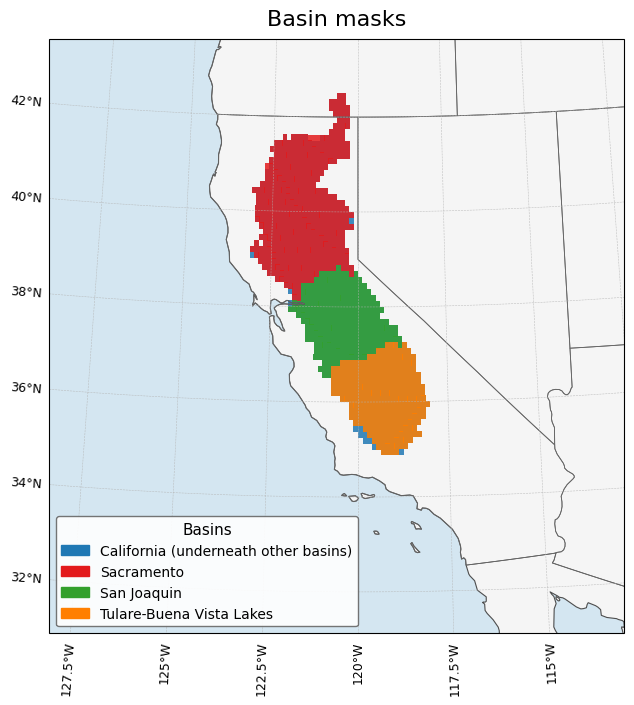

2026-01-20 09:06:44 - INFO - Done.


In [50]:
import xarray as xr
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import numpy as np
import os

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except ImportError:
    ccrs = None
    cfeature = None

# Pad the map around the basins.
north_lat_pad = 1.0
south_lat_pad = 4.0
west_lon_pad  = 5.0
east_lon_pad  = 5.0

# Directory that should contain NLDAS basin masks
masks_dir = options.project_root / "input_data" / "masks"
logging.info(f"Looking for basin masks in: {os.fspath(masks_dir)}")

mask_files = sorted(masks_dir.glob("NLDAS_*_mask.nc"))

if not mask_files:
    logging.warning("No NLDAS_*_mask.nc files found; skipping basin mask map.")
elif ccrs is None or cfeature is None:
    logging.error(
        "cartopy is not installed; cannot make the requested basin map.\n"
        "Install with `pip install cartopy` and re-run this cell."
    )
else:
    basin_entries = []

    for path in mask_files:
        stem = path.stem  # e.g., "NLDAS_california_mask"
        m = re.match(r"^NLDAS_(.+?)_mask$", stem)
        if not m:
            logging.debug(f"Skipping file with unexpected name pattern: {path.name}")
            continue

        safe_name = m.group(1)  # e.g., "california"
        pretty_name = options.reverse_safename_map.get(safe_name, safe_name)

        ds = xr.open_dataset(path)
        mask_da = ds["mask"]  # dims (lat, lon) with values 0/1
        basin_entries.append(
            {
                "safe_name": safe_name,
                "pretty_name": pretty_name,
                "mask": mask_da,
                "path": path,
            }
        )
        logging.info(f"Found mask for basin '{pretty_name}' in {os.fspath(path)}")
        ds.close()

    if not basin_entries:
        logging.warning("Found NLDAS_*_mask.nc files, but none matched the expected naming pattern.")
    else:
        # Sort so that California (if present) is plotted FIRST (under others)
        preferred_order = ["California", "Sacramento", "San Joaquin", "Tulare-Buena Vista Lakes"]

        def sort_key(entry):
            name = entry["pretty_name"]
            if name == "California":
                return (0, 0)  # lowest priority value → drawn first
            if name in preferred_order:
                return (1, preferred_order.index(name))
            return (2, name)

        basin_entries.sort(key=sort_key)

        # --- Determine overall extent from basin *mask pixels* only (with a little padding) ---
        basin_lat_vals = []
        basin_lon_vals = []

        for be in basin_entries:
            mask_da = be["mask"]
            vals = mask_da.values
            lats = mask_da["lat"].values
            lons = mask_da["lon"].values

            # indices where mask == 1
            iy, ix = np.where(vals == 1)
            if iy.size == 0:
                continue  # skip empty masks just in case

            basin_lat_vals.append(lats[iy])
            basin_lon_vals.append(lons[ix])

        if not basin_lat_vals or not basin_lon_vals:
            logging.warning("Masks contain no nonzero pixels; falling back to full grid extent.")
            all_lats = np.concatenate([be["mask"]["lat"].values for be in basin_entries])
            all_lons = np.concatenate([be["mask"]["lon"].values for be in basin_entries])
        else:
            all_lats = np.concatenate(basin_lat_vals)
            all_lons = np.concatenate(basin_lon_vals)

        extent = [
            float(all_lons.min() - west_lon_pad),
            float(all_lons.max() + east_lon_pad),
            float(all_lats.min() - south_lat_pad),
            float(all_lats.max() + north_lat_pad),
        ]


        # --- Map setup: use an equal-area projection centered on California ---
        pc = ccrs.PlateCarree()
        proj = ccrs.AlbersEqualArea(central_longitude=-120, central_latitude=37)

        fig = plt.figure(figsize=(6.5, 7.5))
        ax = plt.axes(projection=proj)

        ax.set_extent(extent, crs=pc)

        # High-quality land/ocean + coastlines/borders
        ax.add_feature(cfeature.LAND.with_scale("50m"),
                       facecolor="#f5f5f5", edgecolor="none")
        ax.add_feature(cfeature.OCEAN.with_scale("50m"),
                       facecolor="#d4e6f1", edgecolor="none")
        ax.coastlines(resolution="50m", linewidth=0.8, color="0.3")
        ax.add_feature(cfeature.BORDERS.with_scale("50m"),
                       linewidth=0.6, edgecolor="0.3")
        ax.add_feature(cfeature.STATES.with_scale("50m"),
                       linewidth=0.6, edgecolor="0.4")

        # Gridlines with labels
        gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                          color="0.7", alpha=0.8, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 9}
        gl.ylabel_style = {"size": 9}

        # Keep aspect reasonable
        ax.set_aspect("equal", adjustable="box")

        # Colorblind-friendly palette for up to four basins
        basin_colors = ["#1f78b4", "#e31a1c", "#33a02c", "#ff7f00"]
        legend_patches = []

        for i, entry in enumerate(basin_entries):
            # If the California basin is here and not alone, note that it
            # is also present underneath other basins because it might be
            # partially or completely obscured.
            if len(basin_entries) == 1 or entry["pretty_name"] != "California":
                basin_name = entry["pretty_name"]
            else:
                basin_name = entry["pretty_name"] + " (underneath other basins)"

            mask_da = entry["mask"]
            lats = mask_da["lat"].values
            lons = mask_da["lon"].values
            vals = mask_da.values

            # Mask out zeros so we ONLY draw cells where mask == 1
            masked_vals = np.ma.masked_where(vals != 1, vals)

            color = basin_colors[i % len(basin_colors)]
            cmap = ListedColormap([color])

            # pcolormesh will only draw where masked_vals is not masked
            ax.pcolormesh(
                lons,
                lats,
                masked_vals,
                cmap=cmap,
                shading="nearest",
                transform=pc,
                alpha=0.85,
            )

            legend_patches.append(mpatches.Patch(color=color, label=basin_name))

        ax.set_title("Basin masks", fontsize=options.title_font, pad=10)

        # Legend with clean frame
        leg = ax.legend(
            handles=legend_patches,
            title="Basins",
            loc="lower left",
            frameon=True,
            framealpha=0.9,
            fontsize=10,
            title_fontsize=11,
        )
        leg.get_frame().set_edgecolor("0.4")

        plt.tight_layout()
        plt.show()

logging.info("Done.")


## Input CSVs and output filename templates

The `compute_groundwater.py` script expects masked time series CSVs in `options.timeseries_dir`,
with names like:

- `anomaly_timeseries_GRACE_<basin_safename>_mask.csv`
- `anomaly_timeseries_<SWE_MODEL>_<basin_safename>_mask.csv`
- `anomaly_timeseries_<RESERVOIRS_MODEL>_<basin_safename>_mask.csv`
- For soil moisture (NLDAS), we pick the **latest** matching CSV.

We now reproduce that logic to turn our placeholder names into real paths.
If the default placeholders are left unchanged, we build the standard filenames.


In [51]:
def configure_paths(options: GroundwaterOptions) -> None:
    """Mimic the path-handling behavior from compute_groundwater.py."""
    basin_title = ra.safestring(options.args.basin)

    # GRACE
    if options.args.grace == options.default_grace_csv:
        options.args.grace = (options.timeseries_dir / f"anomaly_timeseries_GRACE_{basin_title}_mask.csv").resolve()
        logging.info(f"Using GRACE data from {options.args.grace}")

    # SWE
    if options.args.swe == options.default_swe_csv:
        options.args.swe = (
            options.timeseries_dir / f"anomaly_timeseries_{options.swe_model}_{basin_title}_mask.csv"
        ).resolve()
        logging.info(f"Using {options.swe_model} data from {options.args.swe}")

    # Reservoirs
    if options.args.reservoirs == options.default_reservoirs_csv:
        options.args.reservoirs = (
            options.timeseries_dir / f"anomaly_timeseries_{options.reservoirs_model}_{basin_title}_mask.csv"
        ).resolve()
        logging.info(f"Using {options.reservoirs_model} data from {options.args.reservoirs}")

    # Soil moisture (search for latest file)
    if options.args.soilm == options.default_soil_moisture_csv:
        glob_pattern = f"*{options.soil_moisture_model}_{basin_title}*.csv"
        logging.debug(f"Looking for soil moisture files with pattern: {glob_pattern}")
        soil_moisture_files = list(options.timeseries_dir.glob(glob_pattern))
        if soil_moisture_files:
            options.args.soilm = max(soil_moisture_files, key=os.path.getctime)
            logging.info(f"Using {options.soil_moisture_model} data from {options.args.soilm}")
        else:
            raise FileNotFoundError(f"No {options.soil_moisture_model} files found for {options.args.basin}.")

    # Output filename
    if options.args.output == options.default_output_csv:
        timestamp   = ra.parse_datetime("NOW", timezone="America/Los_Angeles").strftime("%Y%m%d-%H%M%S")
        basin_title = ra.safestring(options.args.basin)
        options.args.output = (
            options.output_dir
            / f"anomaly_timeseries_groundwater_{basin_title}_"
              "DATA_START_to_DATA_END_monthly_unsmoothed_created_on_"
              f"{timestamp}.csv"
        )
        logging.info(f"Output base path template: {options.args.output}")
    else:
        logging.info(f"Output will be saved to {options.args.output}")


configure_paths(options)
logging.info("Done.")

2026-01-20 09:06:44 - INFO - Using GRACE data from /Users/killett/GRACE/CA-groundwater/repo/input_data/masked_timeseries/anomaly_timeseries_GRACE_tulare-buena_vista_lakes_mask.csv
2026-01-20 09:06:44 - INFO - Using SNODAS data from /Users/killett/GRACE/CA-groundwater/repo/input_data/masked_timeseries/anomaly_timeseries_SNODAS_tulare-buena_vista_lakes_mask.csv
2026-01-20 09:06:44 - INFO - Using CDEC data from /Users/killett/GRACE/CA-groundwater/repo/input_data/masked_timeseries/anomaly_timeseries_CDEC_tulare-buena_vista_lakes_mask.csv
2026-01-20 09:06:44 - INFO - Using NLDAS data from /Users/killett/GRACE/CA-groundwater/repo/input_data/masked_timeseries/anomaly_timeseries_NLDAS_tulare-buena_vista_lakes_mask_20260116_152522.csv
2026-01-20 09:06:44 - INFO - Output base path template: /Users/killett/GRACE/CA-groundwater/repo/output/anomaly_timeseries_groundwater_tulare-buena_vista_lakes_DATA_START_to_DATA_END_monthly_unsmoothed_created_on_20260120-090644.csv
2026-01-20 09:06:44 - INFO - Do

## Loading the component time series

Each component (GRACE, SWE, soil moisture, reservoirs) is stored as a CSV with:

- A `date` column (any ISO-style date/time string).
- One column for values (e.g., mm water equivalent).
- One column for uncertainties (standard deviation).

We’ll define helper functions:

1. `load_series` – read a CSV, align everything to the middle of the month,  
   and rename data columns to `["value", "error"]`.
2. `show_monthly_duplicates` – log any duplicated months.
3. `_read_csv_header_attrs` – read JSON-style metadata from commented header lines.
4. `_write_df_with_header` – write CSV with a multi-section commented header.


In [52]:
def load_series(path: str | os.PathLike[str],
                date_col: str = "date",
                target_day_of_month: int = 15) -> pd.DataFrame:
    """
    Load a time series CSV with one date column and two data columns.
    The data columns are renamed to ["value","error"], and dates are
    aligned to the given day of month.
    """
    logging.info(
        f"Loading time series from {path} with date column '{date_col}', "
        f"setting the day of the month to {target_day_of_month}."
    )
    df = pd.read_csv(
        path,
        comment="#",
        skip_blank_lines=True,
        converters={date_col: lambda x: pd.to_datetime(x).replace(day=target_day_of_month)},
    )

    df = df.set_index(date_col)

    # Resample to monthly start, then shift to target day
    df = df.resample("MS").first()
    df.index = df.index + pd.DateOffset(days=target_day_of_month - 1)

    data_cols = list(df.columns)
    if len(data_cols) != 2:
        raise ValueError(f"Expected exactly two data columns, got {data_cols!r}")

    df = df.rename(columns={data_cols[0]: "value", data_cols[1]: "error"})
    return df[["value", "error"]]


def show_monthly_duplicates(df: pd.DataFrame, name: str) -> None:
    """Log any duplicate months in the DataFrame index."""
    dup_idx = df.index[df.index.duplicated(keep=False)]
    if not dup_idx.empty:
        logging.info(f"\n{name} has {len(dup_idx)} total rows on these duplicate months:")
        for month in sorted(dup_idx.unique()):
            logging.info(f"\n–– {month.date()} ––")
            logging.info(df.loc[month])


def _read_csv_header_attrs(path: str | os.PathLike[str]) -> dict[str, list[str]]:
    """
    Read top-of-file commented header lines of the strict form:
        # key: [json-array]
    Stop at the first non-comment line. Returns {key: list[str]}.
    """
    header: dict[str, list[str]] = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.startswith("#"):
                break
            text = line[1:].strip()
            # Bare URL case (http://..., ftp://..., etc.)
            m = re.match(r'^([A-Za-z][A-Za-z0-9+.\-]*)://.+$', text)
            if m:
                header[m.group(1)] = [text]
                continue
            if not text or ":" not in text:
                continue
            key, raw = text.split(":", 1)
            key = key.strip()
            raw = raw.strip()
            try:
                val = json.loads(raw)
                if isinstance(val, list):
                    # Special handling for key == "history"
                    if key.lower() == "history" and len(val) > 1:
                        ts = []
                        for item in val:
                            mm = re.search(r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}", str(item))
                            if mm:
                                try:
                                    ts.append(dt.datetime.fromisoformat(mm.group(0)))
                                except Exception:
                                    pass
                        if ts:
                            latest = max(ts)
                            header[key] = [f"most recent created on date: {latest.isoformat()}"]
                            continue
                    header[key] = [str(x) for x in val]
                else:
                    header[key] = [str(val)]
            except Exception:
                header[key] = [raw]
    return header


def _write_df_with_header(df: pd.DataFrame,
                          out_path: os.PathLike[str] | str,
                          index_label: str = "date",
                          sections: dict[str, dict[str, list[str]]] | None = None) -> None:
    """
    Write a multi-section commented header followed by the CSV body.

    sections: {"soil_moisture": {...}, "snow_water_equivalent": {...}, ...}
              Each inner dict maps key -> list[str].
    """
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    with open(out_path, "w", newline="", encoding="utf-8") as fh:
        if sections:
            order = ["soil_moisture", "snow_water_equivalent", "reservoirs", "grace"]
            for section in order:
                fh.write(f"# === {section} ===\n")
                attrs = sections.get(section, {}) if isinstance(sections, dict) else {}
                for k, vlist in attrs.items():
                    fh.write(f"# {k}: {json.dumps(list(vlist), ensure_ascii=False)}\n")
                fh.write("#\n")
        df.to_csv(fh, index_label=index_label)

    logging.info(f"Wrote {out_path}")


logging.info("Done.")

2026-01-20 09:06:45 - INFO - Done.


## Mean removal over a baseline period

We want **anomalies**, not absolute storage. So for each component we:

1. Choose a baseline period (from `options.baseline_start` and `options.baseline_end`).
2. Compute the mean over that period.
3. Subtract that mean from the full time series.

The function `ra.compute_baseline` (from `run_all.py`) finds a sensible baseline
window that overlaps the data and the requested baseline. The helper below
`remove_mean` does the subtraction for a single series.


In [53]:
def remove_mean(series:         pd.Series,
                baseline_start: pd.Timestamp | dt.datetime | str,
                baseline_end:   pd.Timestamp | dt.datetime | str) -> pd.Series:
    """
    Subtracts the mean of 'series' over [baseline_start, baseline_end] from
    the entire series, returning anomalies.
    """
    start = pd.to_datetime(baseline_start)
    end   = pd.to_datetime(baseline_end)

    window = series.loc[start:end]
    μ = window.mean()
    logging.info(f"Removing mean {μ:.3f} from '{series.name}' over {baseline_start} to {baseline_end}")

    return series - μ


logging.info("Done.")

2026-01-20 09:06:46 - INFO - Done.


## Compute groundwater anomalies and propagated uncertainty

We now combine the four components into one DataFrame:

- `grace` – total water storage anomaly
- `swe` – snow water equivalent anomaly
- `soilm` – soil moisture anomaly
- `reservoirs` – reservoir storage anomaly

Then we compute groundwater as:

\[
\text{groundwater} = \text{grace} - (\text{swe} + \text{soilm} + \text{reservoirs})
\]

For uncertainties, assuming the errors are independent:

\[
\sigma_{\text{gw}} = \sqrt{\sigma_{\text{grace}}^2
                         + \sigma_{\text{swe}}^2
                         + \sigma_{\text{soilm}}^2
                         + \sigma_{\text{reservoirs}}^2 }
\]

This mirrors the logic in `compute_groundwater.py`.


In [54]:
def compute_groundwater(options:    GroundwaterOptions,
                        grace:      pd.DataFrame,
                        swe:        pd.DataFrame,
                        soilm:      pd.DataFrame,
                        reservoirs: pd.DataFrame) -> pd.DataFrame:
    """
    Align the four series on shared dates, remove long-term means,
    compute groundwater anomalies, and propagate uncertainties.
    Returns a DataFrame with columns ["groundwater", "error"].
    """
    df = pd.DataFrame({
        "grace":          grace["value"],
        "swe":            swe["value"],
        "soilm":          soilm["value"],
        "reservoirs":     reservoirs["value"],
        "err_grace":      grace["error"],
        "err_swe":        swe["error"],
        "err_soilm":      soilm["error"],
        "err_reservoirs": reservoirs["error"],
    })

    logging.debug(f"DataFrame overview before dropping missing data:\n{df.describe()}")

    logging.info("Dropping any dates with missing data across all components...")
    df = df.dropna()
    logging.debug(f"DataFrame overview after dropping missing data:\n{df.describe()}")

    data_start = df.index.min()
    data_end   = df.index.max()
    logging.info(f"Data start: {data_start.date()}, data end: {data_end.date()}")

    # Baseline handling depends on options.baseline_mode
    mode = getattr(options, "baseline_mode", 1)

    if mode == 1:
        # Original behavior: use baseline_start / baseline_end + compute_baseline
        options.actual_baseline_start, options.actual_baseline_end = ra.compute_baseline(
            data_start, data_end, options.baseline_start, options.baseline_end
        )
        logging.info(
            f"Using baseline interval {options.actual_baseline_start.date()} "
            f"to {options.actual_baseline_end.date()} for mean removal."
        )

        logging.info("Removing long-term means from each series (baseline_mode = 1)...")
        for col in ["grace", "swe", "soilm", "reservoirs"]:
            df[col] = remove_mean(df[col], options.actual_baseline_start, options.actual_baseline_end)

    elif mode == 2:
        # New behavior: subtract the value at the first data point
        logging.info("Baseline_mode = 2: subtracting the first data point from each series.")
        first_timestamp = df.index.min()
        options.actual_baseline_start = first_timestamp
        options.actual_baseline_end   = first_timestamp

        for col in ["grace", "swe", "soilm", "reservoirs"]:
            base_val = df[col].iloc[0]
            logging.debug(
                f"Subtracting initial value {base_val} from '{col}' at {first_timestamp.date()}"
            )
            df[col] = df[col] - base_val

    else:
        raise ValueError(f"Unknown baseline_mode={mode}; expected 1 or 2.")

    logging.debug(f"All series have been baseline-adjusted:\n{df.describe()}")


    # Groundwater anomaly and propagated error
    df["groundwater"] = df["grace"] - (df["swe"] + df["soilm"] + df["reservoirs"])
    df["error"] = np.sqrt(
        df["err_grace"]**2 + df["err_swe"]**2 + df["err_soilm"]**2 + df["err_reservoirs"]**2
    )

    return df[["groundwater", "error"]]


logging.info("Done.")

2026-01-20 09:06:46 - INFO - Done.


## Smoothing and yearly averages

Once we have the monthly groundwater anomalies, we often want:

1. A **smoothed monthly series** (e.g. 3-month centered moving average).
2. **Calendar-year averages** (Jan–Dec).
3. **Water-year averages** (Oct–Sep), common in hydrology.

We now implement:

- `smooth_timeseries` – centered rolling mean.
- `average_timeseries` – calendar vs. water year averaging.


In [55]:
def smooth_timeseries(sw: pd.DataFrame, window: int = 3) -> pd.DataFrame:
    """
    Smooth the groundwater series (and its error) with a centered moving average.

    For the error, propagate monthly 1σ via:
        σ_smooth = sqrt(Σ σ_i^2) / n
    over the window of n contributing months.
    """
    sw_smoothed = sw.copy()

    # Smooth the signal as before
    sw_smoothed["groundwater"] = sw["groundwater"].rolling(
        window=window, center=True, min_periods=1
    ).mean()

    # Custom rolling function for uncertainty propagation
    def _roll_sigma(series: pd.Series) -> float:
        s = series.dropna()
        n = len(s)
        if n == 0:
            return np.nan
        return np.sqrt((s ** 2).sum()) / n

    sw_smoothed["error"] = sw["error"].rolling(
        window=window, center=True, min_periods=1
    ).apply(_roll_sigma, raw=False)

    return sw_smoothed


def average_timeseries(sw: pd.DataFrame, year_type: str = "calendar") -> pd.DataFrame:
    """
    Aggregate a monthly groundwater series into yearly averages.

    Propagate monthly 1σ via:
        σ_year = sqrt(Σ σ_i^2) / n
    where n is the number of contributing months.

    Returns a DataFrame with columns:
        ["groundwater", "error", "n_months_used"]

    year_type:
        - "calendar": Jan–Dec (centered at mid-year)
        - "water":    Oct–Sep (centered ~April of the water year)
    """
    if year_type not in ("calendar", "water"):
        raise ValueError(f"year_type must be 'calendar' or 'water', got '{year_type}'")

    records: list[tuple[pd.Timestamp, float, float, int]] = []

    if year_type == "calendar":
        # Group by calendar year (based on the index)
        grouped = sw.groupby(sw.index.year)

        for year, df_y in grouped:
            s = df_y["groundwater"].dropna()
            e = df_y["error"].dropna()
            n = len(s)
            if n == 0:
                continue

            mean_gw = s.mean()
            sigma_year = np.sqrt((e ** 2).sum()) / n

            # Match previous behavior: YE-DEC then minus 6 months (~mid-year)
            date_label = pd.Timestamp(year=year, month=12, day=31) - pd.DateOffset(months=6)
            records.append((date_label, mean_gw, sigma_year, n))

    else:
        # Water year: Oct–Sep, labeled by the "water_year"
        df = sw.copy()
        water_year = df.index.to_series().apply(
            lambda d: d.year + 1 if d.month >= 10 else d.year
        )
        df["water_year"] = water_year

        grouped = df.groupby("water_year")
        for wy, df_y in grouped:
            s = df_y["groundwater"].dropna()
            e = df_y["error"].dropna()
            n = len(s)
            if n == 0:
                continue

            mean_gw = s.mean()
            sigma_year = np.sqrt((e ** 2).sum()) / n

            # Match previous water-year centering
            date_label = pd.to_datetime(f"{wy}-09-30") - pd.DateOffset(months=6)
            records.append((date_label, mean_gw, sigma_year, n))

    yearly = pd.DataFrame(
        records,
        columns=["date", "groundwater", "error", "n_months_used"],
    ).set_index("date").sort_index()
    yearly.index.name = "date"
    return yearly


logging.info("Done.")

2026-01-20 09:06:47 - INFO - Done.


## Run the groundwater pipeline

We now bundle everything into a convenience function:

1. Load GRACE, SWE, soil moisture, and reservoir series.
2. Log any duplicate months.
3. Read header metadata from each CSV.
4. Compute groundwater anomalies.
5. Update header metadata with the actual baseline used.
6. Write 4 output CSVs:
   - Monthly **unsmoothed** groundwater
   - Monthly **smoothed** groundwater
   - **Calendar-year** averages
   - **Water-year** averages

We will also return the resulting DataFrames and paths for plotting.


In [56]:
def run_groundwater_pipeline(options: GroundwaterOptions,
                             smoothing_window: int = 3) -> dict:
    """
    Full workflow: load, compute groundwater, smooth, average, write CSVs.

    Returns a dict with:
      {
        "monthly_unsmoothed": sw,
        "monthly_smoothed":   sw_smoothed,
        "calendar_year":      sw_cal_yr,
        "water_year":         sw_wat_yr,
        "paths": {
            "monthly_unsmoothed": Path(...),
            "monthly_smoothed":   Path(...),
            "calendar_year":      Path(...),
            "water_year":         Path(...),
        }
      }
    """
    # ---- 1. Load component series ----
    grace = load_series(options.args.grace)
    logging.info(f"Loaded GRACE data with {len(grace)} entries.")
    show_monthly_duplicates(grace, "GRACE")
    grace_header_attrs = _read_csv_header_attrs(options.args.grace)

    swe = load_series(options.args.swe)
    logging.info(f"Loaded {options.swe_model} data with {len(swe)} entries.")
    show_monthly_duplicates(swe, options.swe_model)
    swe_header_attrs = _read_csv_header_attrs(options.args.swe)

    soil_moisture = load_series(options.args.soilm)
    logging.info(f"Loaded {options.soil_moisture_model} data with {len(soil_moisture)} entries.")
    show_monthly_duplicates(soil_moisture, options.soil_moisture_model)
    soil_header_attrs = _read_csv_header_attrs(options.args.soilm)

    reservoirs = load_series(options.args.reservoirs)
    logging.info(f"Loaded {options.reservoirs_model} data with {len(reservoirs)} entries.")
    show_monthly_duplicates(reservoirs, options.reservoirs_model)
    reservoirs_header_attrs = _read_csv_header_attrs(options.args.reservoirs)

    header_sections = {
        "soil_moisture":         soil_header_attrs,
        "snow_water_equivalent": swe_header_attrs,
        "reservoirs":            reservoirs_header_attrs,
        "grace":                 grace_header_attrs,
    }

    # ---- 2. Compute groundwater anomalies ----
    sw = compute_groundwater(options, grace, swe, soil_moisture, reservoirs)
    logging.info(f"Computed groundwater series with {len(sw)} entries.")

    # Add baseline info to headers, depending on baseline_mode
    mode = getattr(options, "baseline_mode", 1)

    if mode == 1:
        baseline_start_str = options.actual_baseline_start.strftime("%Y-%m-%d")
        baseline_end_str   = options.actual_baseline_end.strftime("%Y-%m-%d")
        for sec in header_sections:
            header_sections[sec]["mean_removal_baseline_start"] = [baseline_start_str]
            header_sections[sec]["mean_removal_baseline_end"]   = [baseline_end_str]
    elif mode == 2:
        desc = "baseline_mode=2: anomalies referenced to first data point"
        for sec in header_sections:
            # Do NOT record baseline_start/baseline_end here; just describe the mode
            header_sections[sec]["mean_removal_baseline_description"] = [desc]
    else:
        raise ValueError(f"Unknown baseline_mode={mode}; expected 1 or 2.")

    # Determine data start/end strings for filenames
    data_start_monthly = sw.index.min().strftime("%Y-%m")
    data_end_monthly   = sw.index.max().strftime("%Y-%m")
    data_start_yearly  = sw.index.min().strftime("%Y")
    data_end_yearly    = sw.index.max().strftime("%Y")

    # ---- 3. Write monthly unsmoothed ----
    monthly_unsmoothed_output_path = Path(options.args.output)
    if "DATA_START_to_DATA_END" in monthly_unsmoothed_output_path.name:
        name = monthly_unsmoothed_output_path.name
        name = name.replace("DATA_START", data_start_monthly).replace("DATA_END", data_end_monthly)
        monthly_unsmoothed_output_path = monthly_unsmoothed_output_path.with_name(name)

    _write_df_with_header(sw, monthly_unsmoothed_output_path,
                          index_label="date", sections=header_sections)
    logging.info(f"Groundwater series (monthly, unsmoothed) written to {monthly_unsmoothed_output_path}")

    # ---- 4. Smooth and write monthly smoothed ----
    logging.info(f"Smoothing groundwater series with a {smoothing_window}-month centered moving average.")
    sw_smoothed = smooth_timeseries(sw, window=smoothing_window)

    smoothed_output_path = monthly_unsmoothed_output_path.with_name(
        monthly_unsmoothed_output_path.name.replace(
            "monthly_unsmoothed", f"monthly_smoothed_{smoothing_window}mo"
        )
    )
    _write_df_with_header(sw_smoothed, smoothed_output_path,
                          index_label="date", sections=header_sections)
    logging.info(f"Groundwater series (monthly, smoothed) written to {smoothed_output_path}")

    # ---- 5. Calendar-year averages ----
    logging.info("Computing calendar-year averages of the groundwater series.")
    sw_cal_yr = average_timeseries(sw, year_type="calendar")

    # If baseline_mode=2, also subtract the first yearly data point (calendar-year series)
    if getattr(options, "baseline_mode", 1) == 2 and not sw_cal_yr.empty:
        base_val_cal = sw_cal_yr["groundwater"].iloc[0]
        logging.info(
            f"baseline_mode=2: subtracting first calendar-year groundwater value "
            f"({base_val_cal}) from yearly series."
        )
        sw_cal_yr["groundwater"] = sw_cal_yr["groundwater"] - base_val_cal

    cal_yr_output_path = monthly_unsmoothed_output_path.with_name(
        monthly_unsmoothed_output_path.name.replace("monthly_unsmoothed", "calendar_year_averages")
    )
    # Replace year placeholders if they exist
    if "DATA_START" in cal_yr_output_path.name or "DATA_END" in cal_yr_output_path.name:
        name = cal_yr_output_path.name
        name = name.replace("DATA_START", data_start_yearly).replace("DATA_END", data_end_yearly)
        cal_yr_output_path = cal_yr_output_path.with_name(name)

    _write_df_with_header(sw_cal_yr, cal_yr_output_path,
                          index_label="date", sections=header_sections)
    logging.info(f"Groundwater series (calendar-year averages) written to {cal_yr_output_path}")

    # ---- 6. Water-year averages ----
    logging.info("Computing water-year averages of the groundwater series.")
    sw_wat_yr = average_timeseries(sw, year_type="water")

    # If baseline_mode=2, also subtract the first yearly data point (water-year series)
    if getattr(options, "baseline_mode", 1) == 2 and not sw_wat_yr.empty:
        base_val_wat = sw_wat_yr["groundwater"].iloc[0]
        logging.info(
            f"baseline_mode=2: subtracting first water-year groundwater value "
            f"({base_val_wat}) from yearly series."
        )
        sw_wat_yr["groundwater"] = sw_wat_yr["groundwater"] - base_val_wat

    wat_yr_output_path = monthly_unsmoothed_output_path.with_name(
        monthly_unsmoothed_output_path.name.replace("monthly_unsmoothed", "water_year_averages")
    )
    if "DATA_START" in wat_yr_output_path.name or "DATA_END" in wat_yr_output_path.name:
        name = wat_yr_output_path.name
        name = name.replace("DATA_START", data_start_yearly).replace("DATA_END", data_end_yearly)
        wat_yr_output_path = wat_yr_output_path.with_name(name)

    _write_df_with_header(sw_wat_yr, wat_yr_output_path,
                          index_label="date", sections=header_sections)
    logging.info(f"Groundwater series (water-year averages) written to {wat_yr_output_path}")

    return {
        "monthly_unsmoothed": sw,
        "monthly_smoothed":   sw_smoothed,
        "calendar_year":      sw_cal_yr,
        "water_year":         sw_wat_yr,
        "paths": {
            "monthly_unsmoothed": monthly_unsmoothed_output_path,
            "monthly_smoothed":   smoothed_output_path,
            "calendar_year":      cal_yr_output_path,
            "water_year":         wat_yr_output_path,
        },
    }


# Run the pipeline
results = run_groundwater_pipeline(options, smoothing_window=3)

paths = results["paths"]
key_width = max(len(k) for k in paths)  # for vertical alignment
lines = [
    options.separator_line,
    "Output files written:",
]
for key, path in paths.items():
    # os.fspath() ensures a clean, filesystem-style string
    lines.append(f"  {key:<{key_width}} : {os.fspath(path)}")
lines.append(options.separator_line)
logging.info("\n".join(lines))

logging.info("Done.")

2026-01-20 09:06:48 - INFO - Loading time series from /Users/killett/GRACE/CA-groundwater/repo/input_data/masked_timeseries/anomaly_timeseries_GRACE_tulare-buena_vista_lakes_mask.csv with date column 'date', setting the day of the month to 15.
2026-01-20 09:06:48 - INFO - Loaded GRACE data with 255 entries.
2026-01-20 09:06:48 - INFO - Loading time series from /Users/killett/GRACE/CA-groundwater/repo/input_data/masked_timeseries/anomaly_timeseries_SNODAS_tulare-buena_vista_lakes_mask.csv with date column 'date', setting the day of the month to 15.
2026-01-20 09:06:48 - INFO - Loaded SNODAS data with 265 entries.
2026-01-20 09:06:48 - INFO - Loading time series from /Users/killett/GRACE/CA-groundwater/repo/input_data/masked_timeseries/anomaly_timeseries_NLDAS_tulare-buena_vista_lakes_mask_20260116_152522.csv with date column 'date', setting the day of the month to 15.
2026-01-20 09:06:48 - INFO - Loaded NLDAS data with 264 entries.
2026-01-20 09:06:48 - INFO - Loading time series from /

## Plot groundwater time series

The original `plot_timeseries.py` script (called with `--groundwater`) reads the
groundwater CSVs and produces time-series plots.

Here, we follow a similar idea:

1. Plot monthly unsmoothed groundwater with an uncertainty band.
2. Plot monthly smoothed groundwater (3-month moving average).
3. Plot calendar-year and water-year averages as bar/line plots.

These plots are designed to be:

- **Physically meaningful**: clear units and labels.
- **Visually accessible**: grid, legend, readable fonts.


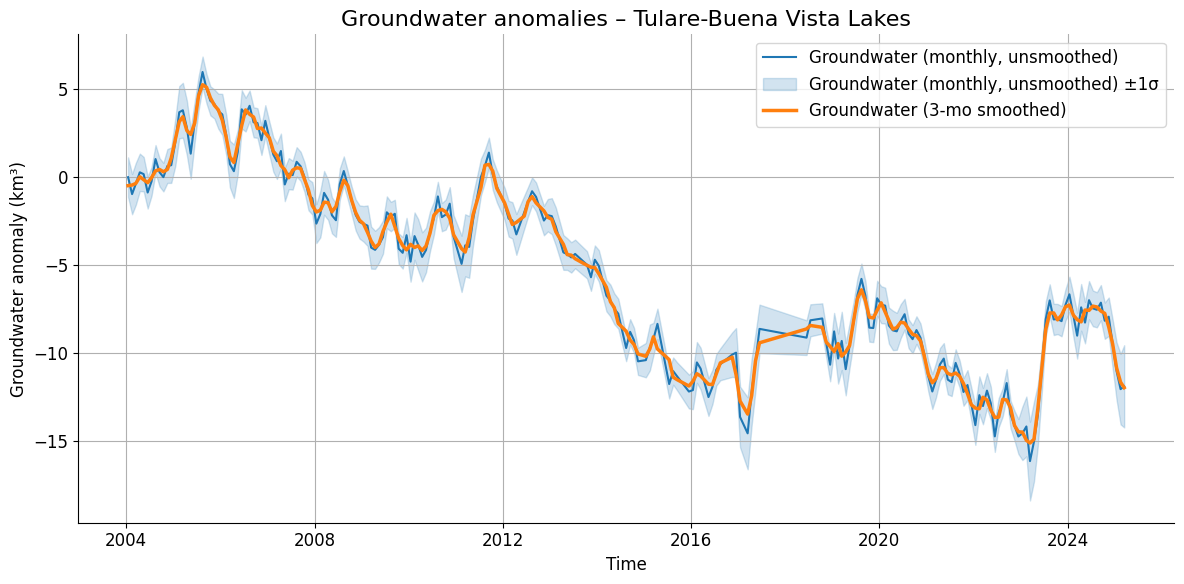

2026-01-20 09:06:52 - INFO - Done.


In [57]:
def plot_with_uncertainty(ax, df: pd.DataFrame, label: str, color_line=None):
    """
    Basic line plot with ±1σ uncertainty band.
    """
    # We let matplotlib choose colors by default; you can pass color_line if desired.
    line = ax.plot(df.index, df["groundwater"], label=label)[0]
    c = line.get_color() if color_line is None else color_line

    ax.fill_between(
        df.index,
        df["groundwater"] - df["error"],
        df["groundwater"] + df["error"],
        alpha=0.2,
        label=f"{label} ±1σ",
        color=c,
    )
    return line


monthly_unsmoothed = results["monthly_unsmoothed"]
monthly_smoothed   = results["monthly_smoothed"]

fig, ax = plt.subplots(figsize=(12, 6))

plot_with_uncertainty(ax, monthly_unsmoothed, label="Groundwater (monthly, unsmoothed)")
ax.plot(
    monthly_smoothed.index,
    monthly_smoothed["groundwater"],
    label="Groundwater (3-mo smoothed)",
    linewidth=2.5,
)

ax.set_title(f"Groundwater anomalies – {options.args.basin}", fontsize = options.title_font)
ax.set_xlabel("Time")
ax.set_ylabel("Groundwater anomaly (km³)")
ax.legend()
plt.tight_layout()
plt.show()

logging.info("Done.")

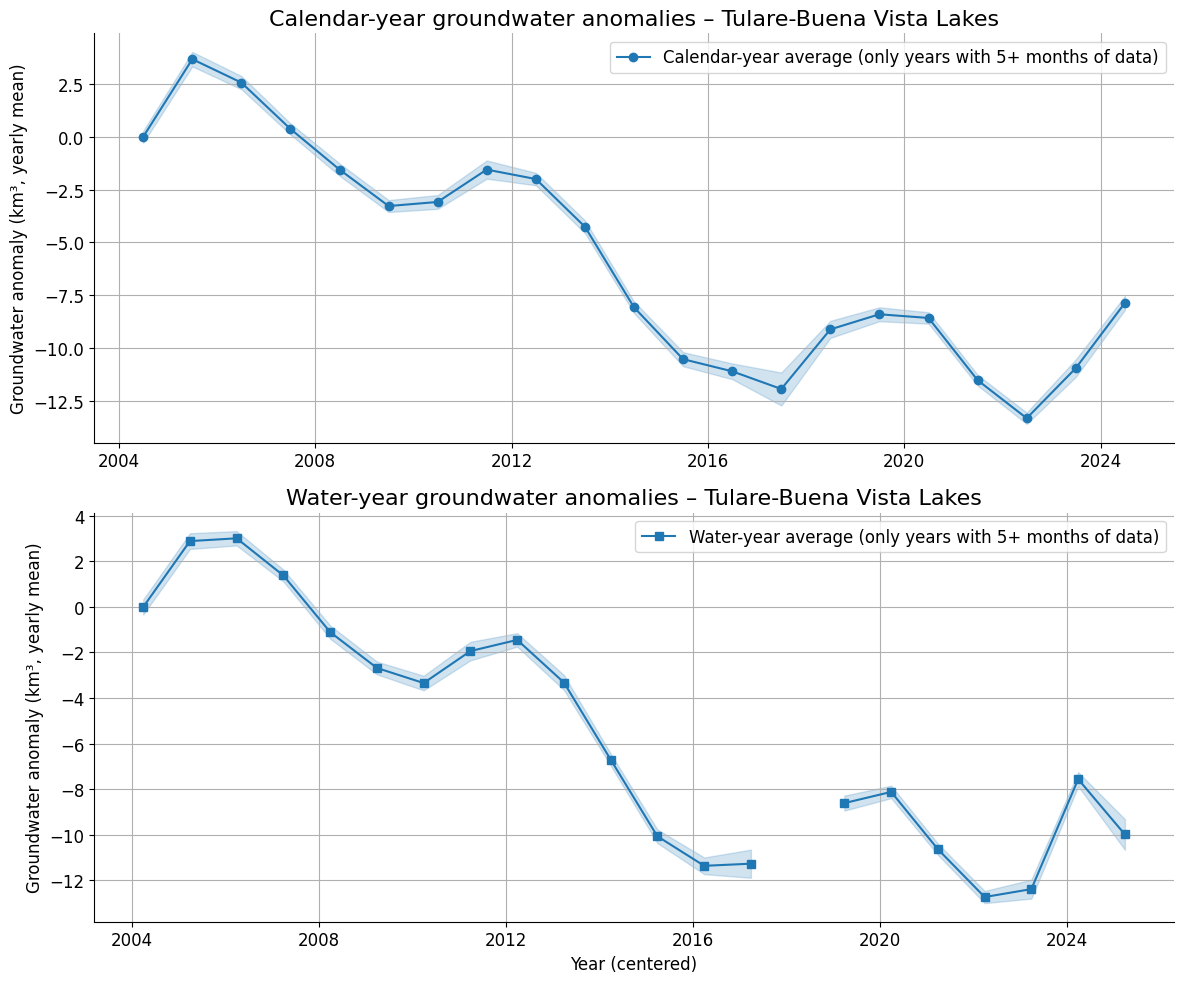

2026-01-20 09:07:10 - INFO - Done.


In [58]:
min_months = 5  # minimum number of months required to plot a yearly value

# Set split_gaps to None in order to plot a single unbroken line that interpolates over missing data.
# Set split_gaps to (e.g.) 2.0 to break lines at gaps ≥ 2 years
split_gaps = 1.5

if   min_months <= 1:
    filter_blurb = ""
elif min_months < 12:
    filter_blurb = f" (only years with {min_months}+ months of data)"
else:
    filter_blurb = " (only years with 12 months of data)"

sw_cal_yr = results["calendar_year"].copy()
sw_wat_yr = results["water_year"].copy()

# Keep only years with sufficient monthly coverage
sw_cal_plot = sw_cal_yr[sw_cal_yr["n_months_used"] >= min_months]
sw_wat_plot = sw_wat_yr[sw_wat_yr["n_months_used"] >= min_months]

# Optional: threshold for breaking line segments, as a Timedelta
gap_threshold = None
if split_gaps is not None:
    gap_threshold = pd.Timedelta(days=365.25 * float(split_gaps))


def _band_with_optional_gaps(ax, df, fmt, base_label):
    """
    Plot yearly data as a line with a ±1σ shaded band.
    If gap_threshold is not None, split both line and band at gaps > threshold.
    """
    if df.empty:
        return

    marker = fmt[0] if fmt else "o"
    linestyle = fmt[1:] if fmt and len(fmt) > 1 else "-"

    def _plot_segment(seg, label, color=None):
        # Plot line (first, so we can capture/force color)
        line = ax.plot(
            seg.index,
            seg["groundwater"],
            marker=marker,
            linestyle=linestyle,
            label=label,
            color=color,
        )[0]
        c = line.get_color() if color is None else color

        # Shaded ±1σ band (no legend entry to avoid duplicates)
        ax.fill_between(
            seg.index,
            seg["groundwater"] - seg["error"],
            seg["groundwater"] + seg["error"],
            alpha=0.2,
            color=c,
            label=None,
        )
        return c

    # No splitting → single segment
    if gap_threshold is None:
        _plot_segment(df, base_label)
        return

    # Split into contiguous segments
    idx_sorted = df.index.sort_values()
    diffs = idx_sorted.to_series().diff()
    break_idx = np.where(diffs > gap_threshold)[0]

    boundaries = list(break_idx) + [len(idx_sorted)]
    start = 0
    first = True
    color = None

    for stop in boundaries:
        seg_idx = idx_sorted[start:stop]
        if len(seg_idx) > 0:
            seg = df.loc[seg_idx]
            if first:
                color = _plot_segment(seg, base_label, color=None)  # choose color
                first = False
            else:
                _plot_segment(seg, label=None, color=color)         # reuse same color
        start = stop


fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# Calendar-year averages
ax1 = axes[0]
_band_with_optional_gaps(
    ax1,
    sw_cal_plot,
    fmt="o-",
    base_label=f"Calendar-year average{filter_blurb}",
)
ax1.set_title(f"Calendar-year groundwater anomalies – {options.args.basin}", fontsize = options.title_font)
ax1.set_ylabel("Groundwater anomaly (km³, yearly mean)")
ax1.legend()
ax1.grid(True)

# Water-year averages
ax2 = axes[1]
_band_with_optional_gaps(
    ax2,
    sw_wat_plot,
    fmt="s-",
    base_label=f"Water-year average{filter_blurb}",
)
ax2.set_title(f"Water-year groundwater anomalies – {options.args.basin}", fontsize = options.title_font)
ax2.set_xlabel("Year (centered)")
ax2.set_ylabel("Groundwater anomaly (km³, yearly mean)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

logging.info("Done.")

## Multi-basin time series: snow, reservoirs, and groundwater

So far we’ve focused on a single basin. In this section, we:

- Scan the project directories for existing **snow (SWE)**, **reservoir**, and **groundwater** anomaly CSVs.
- Use any basins for which we actually have data (we do **not** assume all four basins are present).
- Make three time series panels:
  1. Snow water equivalent anomalies  
  2. Reservoir storage anomalies  
  3. Groundwater anomalies  

Each panel shows **all available basins** as lines with ±1σ uncertainty bands, in the same visual style as the groundwater plot above.

2026-01-20 09:07:13 - INFO - Loading swe series for basin 'California' from /Users/killett/GRACE/CA-groundwater/repo/input_data/masked_timeseries/anomaly_timeseries_SNODAS_california_mask.csv
2026-01-20 09:07:13 - INFO - Loading time series from /Users/killett/GRACE/CA-groundwater/repo/input_data/masked_timeseries/anomaly_timeseries_SNODAS_california_mask.csv with date column 'date', setting the day of the month to 15.
2026-01-20 09:07:13 - INFO - Loading reservoirs series for basin 'California' from /Users/killett/GRACE/CA-groundwater/repo/input_data/masked_timeseries/anomaly_timeseries_CDEC_california_mask.csv
2026-01-20 09:07:13 - INFO - Loading time series from /Users/killett/GRACE/CA-groundwater/repo/input_data/masked_timeseries/anomaly_timeseries_CDEC_california_mask.csv with date column 'date', setting the day of the month to 15.
2026-01-20 09:07:13 - INFO - Loading groundwater series for basin 'California' from /Users/killett/GRACE/CA-groundwater/repo/output/anomaly_timeseries_

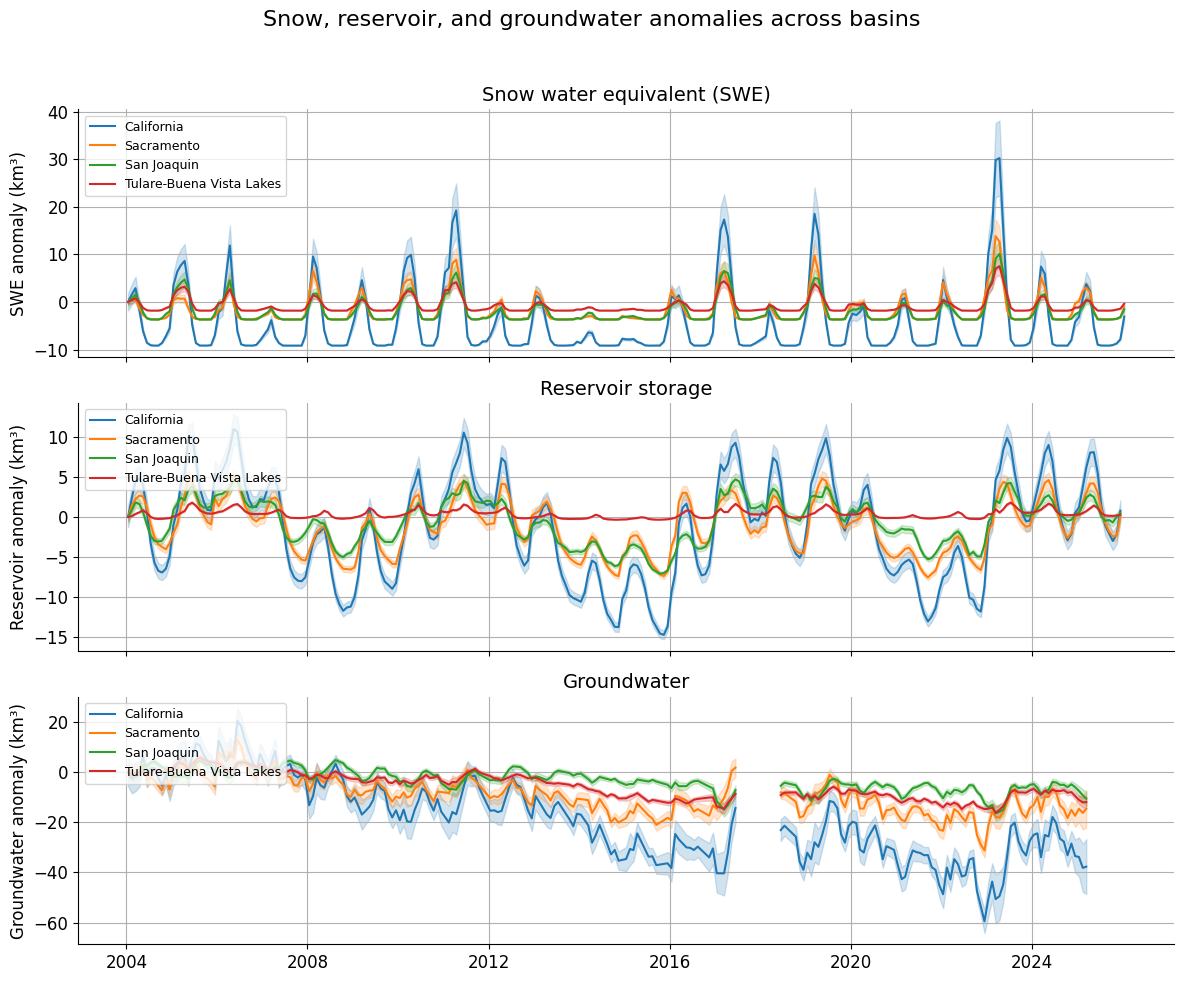

2026-01-20 09:07:16 - INFO - Done.


In [59]:
# Set split_gaps to None in order to plot a single unbroken line that interpolates over missing data.
# Set split_gaps to (e.g.) 2.0 to break lines at gaps ≥ 2 years
split_gaps = 0.5

gap_threshold = None
if split_gaps is not None:
    gap_threshold = pd.Timedelta(days=365.25 * float(split_gaps))

def load_component_series(component: str, basin_name: str) -> pd.DataFrame | None:
    """
    Load a time series for a given component and basin.

    component: "swe", "reservoirs", or "groundwater"
    Returns a DataFrame with index=date and columns ["value", "error"],
    or None if no suitable file is found.
    """
    basin_safe = options.basin_safename_map.get(basin_name)
    if basin_safe is None:
        return None

    if component == "swe":
        # e.g., anomaly_timeseries_SNODAS_california_mask.csv
        path = options.timeseries_dir / f"anomaly_timeseries_{options.swe_model}_{basin_safe}_mask.csv"
    elif component == "reservoirs":
        # e.g., anomaly_timeseries_CDEC_california_mask.csv
        path = options.timeseries_dir / f"anomaly_timeseries_{options.reservoirs_model}_{basin_safe}_mask.csv"
    elif component == "groundwater":
        # Use the most recent monthly_unsmoothed groundwater file for this basin
        pattern = f"anomaly_timeseries_groundwater_{basin_safe}_*_monthly_unsmoothed*.csv"
        candidates = list(options.output_dir.glob(pattern))
        if not candidates:
            return None
        path = max(candidates, key=os.path.getmtime)
    else:
        raise ValueError(f"Unknown component: {component!r}")

    if not path.is_file():
        logging.debug(f"No file found for {component} in basin {basin_name}: {os.fspath(path)}")
        return None

    logging.info(f"Loading {component} series for basin '{basin_name}' from {os.fspath(path)}")
    # Reuse the same loader we used for GRACE/SWE/soil/reservoirs/groundwater
    df = load_series(path, date_col="date")
    return df


def plot_with_uncertainty_generic(
    ax,
    df: pd.DataFrame,
    label: str,
    value_col: str = "value",
    error_col: str = "error",
    color_line=None,
):
    """
    Line + ±1σ band for a generic value/error DataFrame.
    """
    line = ax.plot(df.index, df[value_col], label=label, color=color_line)[0]
    c = line.get_color() if color_line is None else color_line

    ax.fill_between(
        df.index,
        df[value_col] - df[error_col],
        df[value_col] + df[error_col],
        alpha=0.2,
        color=c,
        label=None,        # prevent duplicate legend entry
    )
    return line


def plot_with_uncertainty_generic_split_gaps(
    ax,
    df: pd.DataFrame,
    label: str,
    value_col: str = "value",
    error_col: str = "error",
    color_line=None,
):
    """
    Like plot_with_uncertainty_generic(), but optionally splits line/band at gaps > gap_threshold.
    Uses the outer-scope gap_threshold.
    """
    if df is None or df.empty:
        return

    # Ensure value/error are both present for plotted points
    dfv = df[[value_col, error_col]].dropna()
    if dfv.empty:
        return

    # No splitting -> original behavior
    if gap_threshold is None:
        plot_with_uncertainty_generic(
            ax, dfv, label=label, value_col=value_col, error_col=error_col, color_line=color_line
        )
        return

    idx_sorted = dfv.index.sort_values()
    diffs = idx_sorted.to_series().diff()
    break_idx = np.where(diffs > gap_threshold)[0]
    boundaries = list(break_idx) + [len(idx_sorted)]

    start = 0
    first = True
    color = color_line

    for stop in boundaries:
        seg_idx = idx_sorted[start:stop]
        if len(seg_idx) > 0:
            seg = dfv.loc[seg_idx]

            line = ax.plot(
                seg.index,
                seg[value_col],
                label=label if first else None,
                color=color,
            )[0]
            c = line.get_color() if color is None else color

            ax.fill_between(
                seg.index,
                seg[value_col] - seg[error_col],
                seg[value_col] + seg[error_col],
                alpha=0.2,
                color=c,
                label=None,
            )

            if color is None:
                color = c
            first = False

        start = stop


# Components we want to plot: (internal name, pretty label, y-axis label)
components = [
    ("swe",         "Snow water equivalent (SWE)", "SWE anomaly (km³)"),
    ("reservoirs",  "Reservoir storage",           "Reservoir anomaly (km³)"),
    ("groundwater", "Groundwater",                 "Groundwater anomaly (km³)"),
]

# Gather data: component -> basin_name -> DataFrame
series_by_component: dict[str, dict[str, pd.DataFrame]] = {c[0]: {} for c in components}
basins_with_any_data: set[str] = set()

for basin in options.valid_basins:
    for comp, _, _ in components:
        df = load_component_series(comp, basin)
        if df is not None and not df.empty:
            series_by_component[comp][basin] = df
            basins_with_any_data.add(basin)

if not basins_with_any_data:
    logging.warning("No multi-basin data found for SWE, reservoirs, or groundwater; skipping plots.")
else:
    # Consistent colors per basin across all panels
    basin_list = sorted(basins_with_any_data)
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    basin_color = {b: color_cycle[i % len(color_cycle)] for i, b in enumerate(basin_list)}

    fig, axes = plt.subplots(len(components), 1, figsize=(12, 10), sharex=True)
    if len(components) == 1:
        axes = [axes]

    for ax, (comp, comp_label, y_label) in zip(axes, components):
        comp_dict = series_by_component[comp]

        if not comp_dict:
            ax.text(
                0.5,
                0.5,
                f"No {comp_label.lower()} data found.",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=10,
            )
            ax.set_axis_off()
            continue

        for basin_name, df in comp_dict.items():
            df_plot = df.copy()

            # If baseline_mode == 2, subtract the first value of the series
            if getattr(options, "baseline_mode", 1) == 2 and not df_plot.empty:
                base_val = df_plot["value"].iloc[0]
                logging.debug(
                    f"baseline_mode=2: subtracting first value ({base_val}) for "
                    f"{comp_label} in basin '{basin_name}'"
                )
                df_plot["value"] = df_plot["value"] - base_val

            plot_with_uncertainty_generic_split_gaps(
                ax,
                df_plot,
                label=basin_name,
                value_col="value",
                error_col="error",
                color_line=basin_color.get(basin_name),
            )

        ax.set_ylabel(y_label)
        ax.set_title(comp_label, fontsize=getattr(options, "subtitle_font", options.title_font - 2))
        ax.legend(loc="upper left", fontsize=9)

    # axes[-1].set_xlabel("Time")
    thetitle = "Snow, reservoir, and groundwater anomalies across basins"
    fig.suptitle(thetitle, fontsize=options.title_font)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    fig.savefig(thetitle, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())

logging.info("Done.")

## Plot snow water equivalent, reservoir storage, and groundwater for one basin all on the same axis.

2026-01-20 09:07:17 - INFO - Loading swe series for basin 'Tulare-Buena Vista Lakes' from /Users/killett/GRACE/CA-groundwater/repo/input_data/masked_timeseries/anomaly_timeseries_SNODAS_tulare-buena_vista_lakes_mask.csv
2026-01-20 09:07:17 - INFO - Loading time series from /Users/killett/GRACE/CA-groundwater/repo/input_data/masked_timeseries/anomaly_timeseries_SNODAS_tulare-buena_vista_lakes_mask.csv with date column 'date', setting the day of the month to 15.
2026-01-20 09:07:17 - INFO - Loading reservoirs series for basin 'Tulare-Buena Vista Lakes' from /Users/killett/GRACE/CA-groundwater/repo/input_data/masked_timeseries/anomaly_timeseries_CDEC_tulare-buena_vista_lakes_mask.csv
2026-01-20 09:07:17 - INFO - Loading time series from /Users/killett/GRACE/CA-groundwater/repo/input_data/masked_timeseries/anomaly_timeseries_CDEC_tulare-buena_vista_lakes_mask.csv with date column 'date', setting the day of the month to 15.
2026-01-20 09:07:17 - INFO - Loading groundwater series for basin '

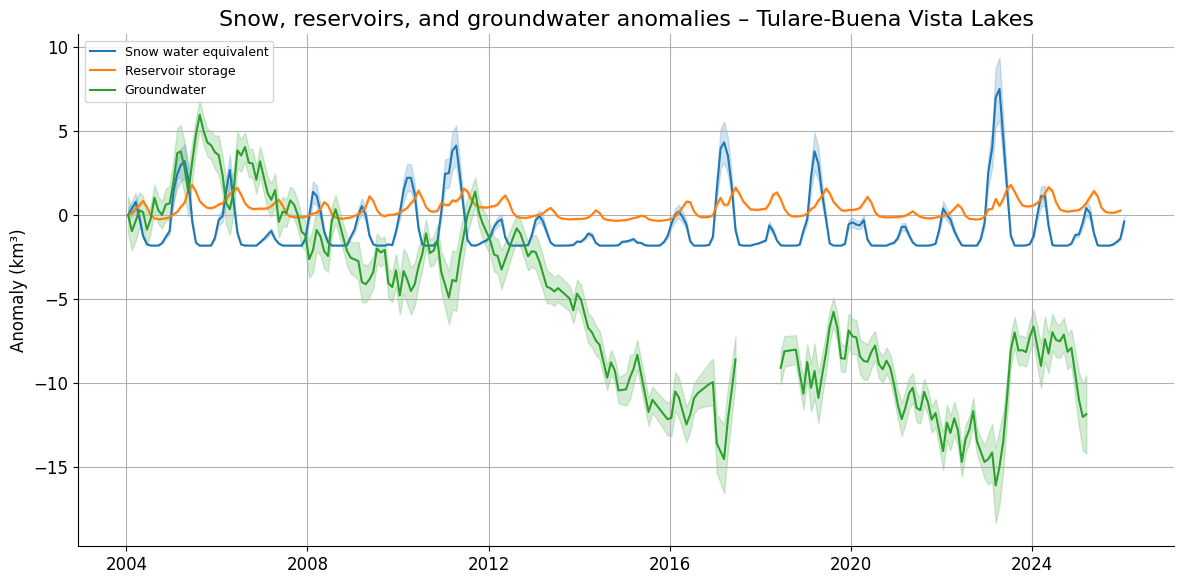

2026-01-20 09:07:18 - INFO - Done.


In [60]:
# Set split_gaps to None in order to plot a single unbroken line that interpolates over missing data.
# Set split_gaps to (e.g.) 2.0 to break lines at gaps ≥ 2 years
split_gaps = 0.5

gap_threshold = None
if split_gaps is not None:
    gap_threshold = pd.Timedelta(days=365.25 * float(split_gaps))

# --- User choice of ['California', 'Sacramento', 'San Joaquin', 'Tulare-Buena Vista Lakes'] ---
# UNCOMMENT THIS LINE IF YOU WANT TO OVERRIDE THE chosen_basin THAT IS SPECIFIED ABOVE!
# chosen_basin = "Sacramento"  # <-- change this (must match one of the above options.valid_basins)

# --- Validate basin selection ---
if chosen_basin not in options.valid_basins:
    raise ValueError(f"chosen_basin={chosen_basin!r} is not in options.valid_basins.\n"
                     f"Valid basins: {options.valid_basins}")

# --- Load the three components for the chosen basin ---
components = [
    ("swe",        "Snow water equivalent"),
    ("reservoirs", "Reservoir storage"),
    ("groundwater","Groundwater"),
]

series: dict[str, pd.DataFrame] = {}
for comp, pretty in components:
    df = load_component_series(comp, chosen_basin)
    if df is None or df.empty:
        logging.warning(f"No data found for {pretty} in basin '{chosen_basin}'.")
        continue
    series[comp] = df

if not series:
    logging.warning(f"No SWE, reservoirs, or groundwater data found for basin '{chosen_basin}'. Skipping plot.")
else:
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot all available series on the same axis
    for comp, pretty in components:
        if comp not in series:
            continue

        df_plot = series[comp].copy()

        # If baseline_mode == 2, subtract the first value of the series
        if getattr(options, "baseline_mode", 1) == 2 and not df_plot.empty:
            base_val = df_plot["value"].iloc[0]
            logging.debug(
                f"baseline_mode=2: subtracting first value ({base_val}) for {pretty} "
                f"in basin '{chosen_basin}'"
            )
            df_plot["value"] = df_plot["value"] - base_val

        plot_with_uncertainty_generic_split_gaps(
            ax,
            df_plot,
            label=pretty,
            value_col="value",
            error_col="error",
            color_line=None,  # let matplotlib cycle colors
        )

    ax.set_title(f"Snow, reservoirs, and groundwater anomalies – {chosen_basin}", fontsize=options.title_font)
    ax.set_ylabel("Anomaly (km³)")
    ax.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()
    fig.savefig(f"Snow, reservoirs, and groundwater anomalies – {chosen_basin}", dpi=300,
                bbox_inches="tight", facecolor=fig.get_facecolor())


logging.info("Done.")

## Wrap-up and next steps

In this notebook, you:

1. Reproduced the logic of `compute_groundwater.py` using a notebook-friendly
   `GroundwaterOptions` class and the local `run_all` module (`import run_all as ra`).
2. Loaded GRACE, snow water equivalent (SWE), soil moisture, and reservoir time series from CSVs.
3. Demeaned each series over a well-defined baseline period using
   `ra.compute_baseline` and the `remove_mean` function.
4. Computed groundwater anomalies and propagated uncertainties assuming independent errors.
5. Generated four groundwater products:
   - Monthly unsmoothed
   - Monthly smoothed (3-month moving average)
   - Calendar-year averages
   - Water-year averages
6. Created basic, publication-quality plots that mimic the idea of
   `plot_timeseries.py --groundwater`.
7. Plotted snow water equivalent, reservoir storage and groundwater for all basins.

### Things to try

- Change the **basin** (e.g., `"Sacramento"`, `"San Joaquin"`).
- Experiment with different **baseline periods** by editing
  `options.baseline_start` and `options.baseline_end`.
- Try other **smoothing windows** (e.g., 6 months) in `run_groundwater_pipeline`.
- Overlay groundwater with GRACE TWS or other components on the same figure to
  see how they relate.

This notebook is designed both as a **teaching resource** and as a convenient
way to tinker with the processing pipeline without having to re-run all the
command-line scripts.
